### Emotion Detection Evaluation | Annotated Sample

### Setup

In [1]:
# Import required libraries 
import time
import requests
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


### Load dataset

In [2]:
# Define constants for input and output paths
FILE_PATH = "data/annotated_emotions.xlsx"
TEXT_COL = "text"
EXPECTED_COL = "expected_emotion"
RESULTS_CSV = "emotion_evaluation_results.csv"

# Load the annotated dataset
df = pd.read_excel(FILE_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Results CSV path: {RESULTS_CSV}")
df.head()

Dataset shape: (600, 3)
Columns: ['text', 'expected_emotion', 'llm_predict']
Results CSV path: emotion_evaluation_results.csv


,text,expected_emotion,llm_predict
0,This offer feels wildly expensive,FRUSTRATED,FRUSTRATED
1,Why does tax cost so much,FRUSTRATED,FRUSTRATED
2,This price feels wildly expensive,FRUSTRATED,FRUSTRATED
3,Why is the final total still unacceptable,FRUSTRATED,FRUSTRATED
4,I cannot make the quoted total work,FRUSTRATED,FRUSTRATED


### Preprocessing checks

In [3]:
# Basic data quality checks
prep_df = df.copy()
prep_df[TEXT_COL] = prep_df[TEXT_COL].astype(str).str.strip()
prep_df[EXPECTED_COL] = prep_df[EXPECTED_COL].astype(str).str.strip().str.upper()

# Check for missing values in text and label columns
missing_text = prep_df[TEXT_COL].eq("").sum()
missing_label = prep_df[EXPECTED_COL].eq("").sum()
print(f"Empty text rows: {missing_text}")
print(f"Empty label rows: {missing_label}")


Empty text rows: 0
Empty label rows: 0


In [4]:
# Analyze class distribution
class_distribution = (
    prep_df[EXPECTED_COL]
    .value_counts(dropna=False)
    .rename_axis("emotion")
    .reset_index(name="count")
)
class_distribution["pct"] = (class_distribution["count"] / len(prep_df) * 100).round(2)
display(class_distribution)

,emotion,count,pct
0,FRUSTRATED,100,16.67
1,HESITANT,100,16.67
2,NEUTRAL,100,16.67
3,INTERESTED,100,16.67
4,SATISFIED,100,16.67
5,EXCITED,100,16.67


### API helper to Call Springboot Backend of Emotiate

In [5]:
# API endpoint for emotion detection
API_URL = "http://localhost:8080/api/emotion/detect"

# Time gap between requests to avoid hitting rate limits
REQUEST_GAP_S = 2.1
MAX_RETRIES = 5
BACKOFF_BASE = 3.0

# Helper function to call the emotion detection API with retry and backoff
def detect_emotion(text: str) -> str | None:
    for attempt in range(MAX_RETRIES):
        try:
            response = requests.post(
                API_URL,
                headers={"Content-Type": "application/json"},
                json={"userMessage": text},
                timeout=30,
            )

            if response.status_code == 429:
                wait = BACKOFF_BASE * (2 ** attempt)
                tqdm.write(f"[429] Waiting {wait:.0f}s (attempt {attempt + 1}/{MAX_RETRIES})")
                time.sleep(wait)
                continue

            response.raise_for_status()
            return response.json().get("data", {}).get("emotion")

        except requests.exceptions.RequestException as e:
            tqdm.write(f"[ERROR] {text[:60]!r} -> {e}")
            return None

    tqdm.write(f"[FAILED] Gave up after {MAX_RETRIES} retries: {text[:60]!r}")
    return None

### Run evaluation

In [6]:
# Set up evaluation DataFrame 
eval_df = prep_df.copy()
eval_df[EXPECTED_COL] = eval_df[EXPECTED_COL].astype(str).str.strip().str.upper()

# Run emotion predictions
predictions = []
for text in tqdm(eval_df[TEXT_COL], desc="Evaluating", unit="sample"):
    predictions.append(detect_emotion(str(text)))
    time.sleep(REQUEST_GAP_S)

# Store predictions and summarize results
eval_df["llm_predict"] = predictions
successful = sum(p is not None for p in predictions)
print(f"Done. {successful}/{len(predictions)} successful predictions.")

# Save results to CSV
eval_df.to_csv(RESULTS_CSV, index=False)

Evaluating:   0%|          | 0/600 [00:00<?, ?sample/s]

Done. 600/600 successful predictions.


### Results

In [10]:
## Read saved results CSV
results_df = pd.read_csv(RESULTS_CSV)

# Clean columns
results_df[EXPECTED_COL] = results_df[EXPECTED_COL].str.strip().str.upper()
results_df["llm_predict"] = results_df["llm_predict"].str.strip().str.upper()

# Keep only valid predictions
valid = results_df[results_df["llm_predict"].notna() & (results_df["llm_predict"] != "")]

# Accuracy
overall_accuracy = (valid["llm_predict"] == valid[EXPECTED_COL]).mean()
print(f"Overall accuracy: {overall_accuracy:.2%} ({len(valid)} valid / {len(results_df)} total)")


Overall accuracy: 92.17% (600 valid / 600 total)


In [11]:
# Breakdown
breakdown = (
    (valid["llm_predict"] == valid[EXPECTED_COL])
    .groupby(valid[EXPECTED_COL])
    .agg(correct="sum", total="count")
    .assign(accuracy=lambda d: d["correct"] / d["total"])
)

breakdown = breakdown.reset_index().rename(columns={EXPECTED_COL: "emotion"})
display(breakdown)

,emotion,correct,total,accuracy
0,EXCITED,74,100,0.74
1,FRUSTRATED,100,100,1.00
2,HESITANT,96,100,0.96
3,INTERESTED,99,100,0.99
4,NEUTRAL,85,100,0.85
5,SATISFIED,99,100,0.99


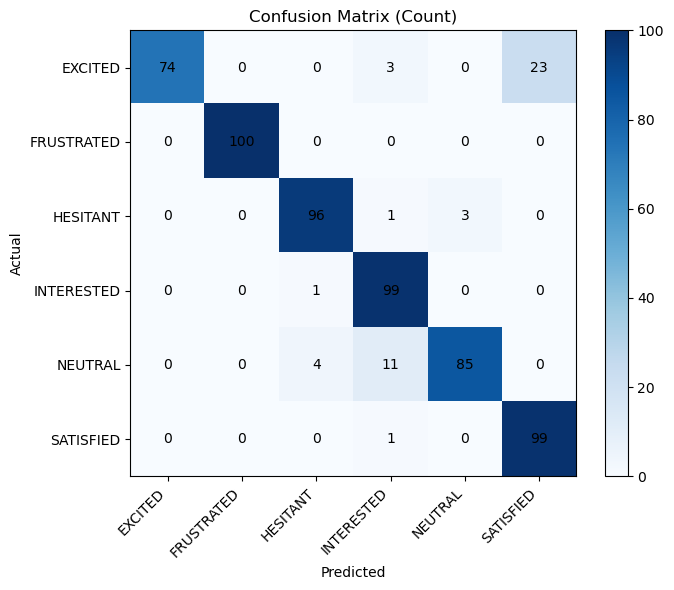

In [12]:
# Plot confusion matrix
labels = sorted(set(valid[EXPECTED_COL].unique()) | set(valid["llm_predict"].unique()))
cm = pd.crosstab(
    valid[EXPECTED_COL],
    valid["llm_predict"],
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

# Set up the figure size and titles
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Confusion Matrix (Count)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



The ED module achieved an overall accuracy of **92.17%**, correctly classifying **553 out of 600 samples**. As each emotion category contained an equal number of instances, the evaluation provides a balanced assessment across all classes.

For positive emotions, the model also performs well, with satisfied achieving an F1-score of 0.89 and excited achieving 0.85. The slight drop here reflects the difficulty in distinguishing between different levels of positive sentiment.

Some confusion is observed between neutral (F1 = 0.90) and interested (F1 = 0.92). This is expected because both often appear as simple questions without clear emotional intensity. The model tends to slightly over-predict interested, which reduces precision but maintains high recall.

The model performs particularly well on clearly expressed emotions. Frustrated achieves near-perfect performance, while hesitant also shows strong results. These findings indicate that emotions with clear linguistic signals are easier to classify accurately.

Overall, the observed patterns are consistent with real-world communication, where emotional expressions are often subtle and overlapping. Most misclassifications occur between closely related emotions rather than unrelated ones. This suggests that the ED module captures realistic conversational behavior while maintaining a high level of accuracy, making it suitable for practical negotiation scenarios.